# Figure 2: Bihar fishnet grid (with India locator inset)

Notebook version of `fig_grid.py`, for interactive use. Not part of the `autofloods` package.

Main panel: Bihar's fishnet grid, large, tile IDs labeled, Bihar state boundary overlaid. Only tiles that actually intersect Bihar are shown (274-277, 313-322, 324-326, 329-330; 19 tiles). Tiles 323, 328, and 331 sit entirely outside Bihar's border in neighbouring states and are excluded from the analysis entirely (not just this figure) -- see the manuscript's Section 2.2 grid description and Section 3 statistics, which were recomputed to match.

Inset (small, corner): India with state boundaries, Bihar highlighted, for geographic context. A `mark_inset` connector marks Bihar's true extent on the India panel and links it to the main panel's top corners (loc1=1, loc2=2), chosen so both connector lines stay in the empty header space above the tile grid rather than crossing the tiles.

Writes `figures/fig_grid.pdf` (vector) and `figures/fig_grid.png` (300 DPI raster; map figures use PNG per the plan's figure style requirements).

In [1]:
import os
import sys

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.patches import FancyArrow
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

sys.path.insert(0, os.path.abspath('.'))
from _boundaries import INDIA_STATES_PATH, BIHAR_PATH, require_boundaries

require_boundaries()

## Config

In [2]:
OUT_DIR = '/home/emlab/projects/current-projects/edge-autofloods/autofloods-manuscript/figures'
GRID_PATH = '/home/emlab/projects/current-projects/edge-autofloods/AutoFloods/resources/india_utm_fishnet_buffer.gpkg'

ALL_BIHAR_TILE_IDS = [274, 275, 276, 277, 313, 314, 315, 316, 317, 318, 319, 320,
                      321, 322, 323, 324, 325, 326, 328, 329, 330, 331]
# 323, 328, 331 don't intersect Bihar's boundary at all -- excluded from
# the analysis entirely (not just this figure), per explicit decision.

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 10

## Load data

In [3]:
grid_gdf = gpd.read_file(GRID_PATH)
all_bihar_tiles = grid_gdf[grid_gdf['ID'].isin(ALL_BIHAR_TILE_IDS)]  # EPSG:4326, matches india_states/bihar
india_states = gpd.read_file(INDIA_STATES_PATH)
bihar_boundary = gpd.read_file(BIHAR_PATH)
bihar_geom = bihar_boundary.geometry.iloc[0]

# Keep only tiles that actually touch Bihar -- drops 323, 328, 331, which
# sit entirely in neighbouring states.
bihar_tiles = all_bihar_tiles[all_bihar_tiles.geometry.intersects(bihar_geom)]
bihar_tiles

ERROR 1: PROJ: proj_create_from_database: Open of /home/ptripathy/miniforge-pypy3/envs/autofloods/share/proj failed


,left,top,zone,dry_month,ID,geometry
273,83.0,28.0,44R,"04,05",274,"MULTIPOLYGON (((82.998 28.002, 84.002 28.002, ..."
274,83.0,27.0,44R,"04,05",275,"MULTIPOLYGON (((82.998 27.002, 84.002 27.002, ..."
275,83.0,26.0,44R,"04,05",276,"MULTIPOLYGON (((82.998 26.002, 84.002 26.002, ..."
276,83.0,25.0,44R,"04,05",277,"MULTIPOLYGON (((82.998 25.002, 84.002 25.002, ..."
312,84.0,28.0,45R,"04,05",313,"MULTIPOLYGON (((83.998 28.002, 85.002 28.002, ..."
313,84.0,27.0,45R,"04,05",314,"MULTIPOLYGON (((83.998 27.002, 85.002 27.002, ..."
314,84.0,26.0,45R,"04,05",315,"MULTIPOLYGON (((83.998 26.002, 85.002 26.002, ..."
315,84.0,25.0,45R,"04,05",316,"MULTIPOLYGON (((83.998 25.002, 85.002 25.002, ..."
316,85.0,27.0,45R,"04,05",317,"MULTIPOLYGON (((84.998 27.002, 86.002 27.002, ..."
317,85.0,26.0,45R,"04,05",318,"MULTIPOLYGON (((84.998 26.002, 86.002 26.002, ..."


## Main panel: Bihar grid, large

(<mpl_toolkits.axes_grid1.inset_locator.BboxPatch at 0x7d1167985690>,
 <mpl_toolkits.axes_grid1.inset_locator.BboxConnector at 0x7d1163cea810>)

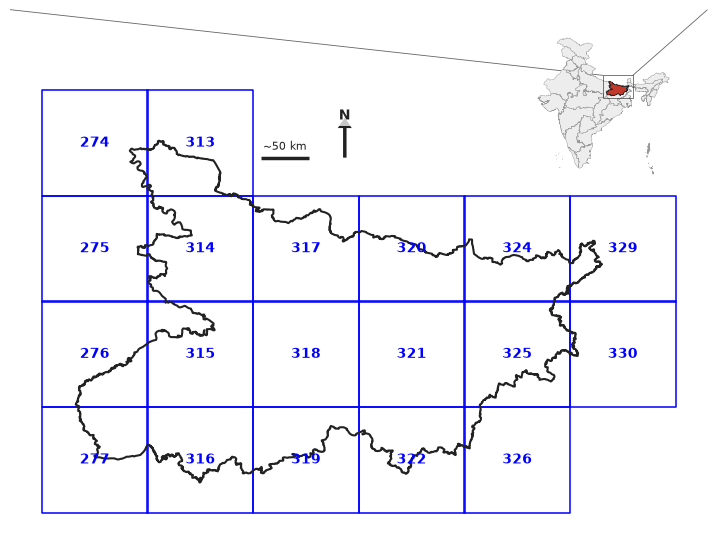

In [4]:

TILE_FILL = 'None'
TILE_EDGE = 'blue'
TEXT_COLOR = 'blue'
BOUNDARY_COLOR = '#222222'
STATE_FILL = '#EDEDED'
BIHAR_HIGHLIGHT = '#C0392B'

fig, ax = plt.subplots(figsize=(9, 9.5))

bihar_tiles.plot(ax=ax, facecolor=TILE_FILL, edgecolor=TILE_EDGE,  linewidth=1.1, zorder=2)
bihar_boundary.boundary.plot(ax=ax, color=BOUNDARY_COLOR, linewidth=1.5, zorder=3)
for _, row in bihar_tiles.iterrows():
    c = row.geometry.centroid
    ax.text(c.x, c.y, str(int(row['ID'])), ha='center', va='center',
            fontsize=10, color=TEXT_COLOR, weight='bold', zorder=4)

# Extent from the actual tile grid, not the Bihar boundary -- the tiles
# extend slightly past Bihar's own border on most sides. Extra headroom
# at the top only, to leave clear room for the India inset without it
# overlapping the tiles.
bounds = bihar_tiles.total_bounds
pad_x = (bounds[2] - bounds[0]) * 0.05
pad_y = (bounds[3] - bounds[1]) * 0.05
pad_top = (bounds[3] - bounds[1]) * 0.19
ax.set_xlim(bounds[0] - pad_x, bounds[2] + pad_x)
ax.set_ylim(bounds[1] - pad_y, bounds[3] + pad_top)
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect('equal')
ax.set_axis_off()  # no plot border



## North arrow + scale bar
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()
dx = xmax - xmin
dy = ymax - ymin
grid_top = bounds[3]
backing = dict(facecolor='white', alpha=0.75, edgecolor='none', pad=2)

arrow_x = xmin + 0.48 * dx
arrow_y0 = grid_top - 0.16 * (bounds[3] - bounds[1])
arrow_len = 0.07 * (bounds[3] - bounds[1])
ax.add_patch(FancyArrow(arrow_x, arrow_y0, 0, arrow_len, width=dx * 0.005,
                         head_width=dx * 0.02, head_length=arrow_len * 0.35,
                         facecolor=BOUNDARY_COLOR, edgecolor='none', zorder=6))
ax.text(arrow_x, arrow_y0 + arrow_len + dy * 0.01, 'N', ha='center', va='bottom',
        fontsize=10, weight='bold', color=BOUNDARY_COLOR, zorder=6, bbox=backing)

bar_km = 50
bar_len_deg = 0.45  # ~50 km at Bihar's latitude
bar_x0 = xmin + 0.36 * dx
bar_y0 = arrow_y0
ax.plot([bar_x0, bar_x0 + bar_len_deg], [bar_y0, bar_y0], color=BOUNDARY_COLOR,
        linewidth=2.5, solid_capstyle='butt', zorder=6,
        path_effects=[pe.withStroke(linewidth=4.5, foreground='white', alpha=0.75)])
ax.text(bar_x0 + bar_len_deg / 2, bar_y0 + dy * 0.01, f'~{bar_km} km', ha='center', va='bottom',
        fontsize=8, color=BOUNDARY_COLOR, zorder=6, bbox=backing)



## Inset: India locator (key map)
inset_h = pad_top * 2
inset_w = inset_h * 0.9  # roughly India's aspect ratio
inset_x0 = xmax - pad_x - inset_w
inset_y0 = grid_top - pad_top * 1.2  # gap between tiles and inset
axins = inset_axes(ax, width='100%', height='100%',
                    bbox_to_anchor=(inset_x0, inset_y0, inset_w, inset_h),
                    bbox_transform=ax.transData, loc='lower left', borderpad=0)
india_states.plot(ax=axins, facecolor=STATE_FILL, edgecolor='#999999', linewidth=0.3, zorder=1)
bihar_boundary.plot(ax=axins, facecolor=BIHAR_HIGHLIGHT, edgecolor=BOUNDARY_COLOR,
                     linewidth=0.4, zorder=2)
axins.set_axis_off()
axins.set_aspect('equal')

# Connector: small rectangle on the India inset marking Bihar's true
# extent (ax's current view limits), with lines to the main panel's
# top corners. loc1=1 (upper right), loc2=2 (upper left) keep both
# connector lines inside the empty header space above the tile grid
# instead of crossing the tiles themselves.
mark_inset(axins, ax, loc1=1, loc2=2, fc='none', ec=BOUNDARY_COLOR,
           linewidth=0.6, alpha=0.7)



## Save

In [5]:
os.makedirs(OUT_DIR, exist_ok=True)
pdf_path = os.path.join(OUT_DIR, 'fig_grid.pdf')
png_path = os.path.join(OUT_DIR, 'fig_grid.png')
fig.savefig(pdf_path, bbox_inches='tight')
fig.savefig(png_path, dpi=300, bbox_inches='tight')
print(f'Wrote {pdf_path}')
print(f'Wrote {png_path}')
print(f'n tiles shown: {len(bihar_tiles)} (dropped: {sorted(set(ALL_BIHAR_TILE_IDS) - set(bihar_tiles["ID"]))})')

Wrote /home/emlab/projects/current-projects/edge-autofloods/autofloods-manuscript/figures/fig_grid.pdf
Wrote /home/emlab/projects/current-projects/edge-autofloods/autofloods-manuscript/figures/fig_grid.png
n tiles shown: 19 (dropped: [323, 328, 331])
